In [23]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from IPython.display import display

# Fase 1 — Análise Exploratória

## 1.1 Carregamento do dataset 

O MNIST é obtido via `fetch_openml`, que baixa a versão 1 da base e a mantém em cache local. A semente global é fixada em 42 para garantir reprodutibilidade em todas as etapas
que envolvem aleatoriedade.

In [24]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Baixando o dataset MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
print("Finalizou o processo de baixar o dataset MNIST!")

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


## 1.2 Dimensionalidade e domínio dos dados

Inspeção das dimensões das matrizes, dos tipos de dados e da faixa de intensidade dos pixels. O objetivo é confirmar a estrutura esperada antes de qualquer transformação e
identificar a escala das features, que determina a necessidade de normalização na Fase 2.

In [25]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Tipo de X: {X.dtype} | Tipo de y: {y.dtype}")
print(f"Intensidade mínima: {X.min()} | máxima: {X.max()}")
print(f"Classes presentes: {np.unique(y)}")

Formato de X: (70000, 784)
Formato de y: (70000,)
Tipo de X: float32 | Tipo de y: uint8
Intensidade mínima: 0.0 | máxima: 255.0
Classes presentes: [0 1 2 3 4 5 6 7 8 9]


## 1.3 Contagem de amostras por classe

Frequência absoluta e relativa de cada dígito. Um desbalanceamento acentuado exigiria reamostragem ou ponderação de classes, além de tornar a acurácia global uma métrica
enganosa.

In [26]:
contagem = pd.Series(y).value_counts().sort_index()
proporcao = (contagem / len(y) * 100).round(2)

resumo_classes = pd.DataFrame({"amostras": contagem, "percentual": proporcao})
resumo_classes.index.name = "digito"
display(resumo_classes)


,amostras,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


## 1.4 Medidas de dispersão do balanceamento

Quantificação do que o gráfico sugere. O desvio-padrão dos percentuais e a razão entre  classe mais e a menos frequente substituem a leitura visual por um critério objetivo de
balanceamento.

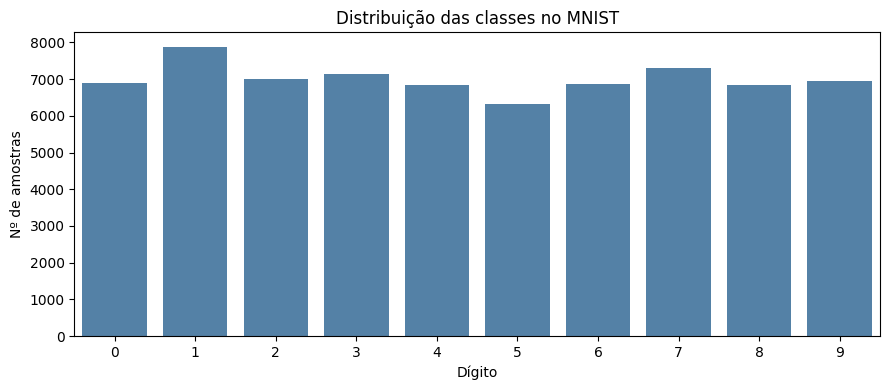

Desvio-padrão dos percentuais: 0.57 p.p.
Razão entre a classe mais e a menos frequente: 1.25:1
Classe mais frequente: 1 | menos frequente: 5


In [27]:

plt.figure(figsize=(9, 4))
sns.barplot(x=contagem.index, y=contagem.values, color="steelblue")
plt.title("Distribuição das classes no MNIST")
plt.xlabel("Dígito")
plt.ylabel("Nº de amostras")
plt.tight_layout()
plt.show()

desvio_padrao = proporcao.std()
razao = contagem.max() / contagem.min()
print(f"Desvio-padrão dos percentuais: {desvio_padrao:.2f} p.p.")
print(f"Razão entre a classe mais e a menos frequente: {razao:.2f}:1")
print(f"Classe mais frequente: {contagem.idxmax()} | menos frequente: {contagem.idxmin()}")

## 1.5 Variabilidade de escrita dentro de cada classe

Cinco exemplares sorteados de cada dígito, com semente fixa para garantir que a grade seja reprodutível. Exibir múltiplas amostras por classe, em vez de uma só, revela a dispersão
intraclasse: o mesmo dígito aparece com inclinações, espessuras de traço e proporções distintas. Essa variação intraclasse não carrega informação sobre o rótulo, e o classificador precisa se tornar invariante a ela — retendo apenas os traços que distinguem um dígito de outro.

A grade também antecipa a dificuldade do problema. Dígitos de classes diferentes podem ocupar regiões de pixel muito semelhantes, o que sugere quais pares tendem a concentrar
os erros na matriz de confusão da Fase 4.

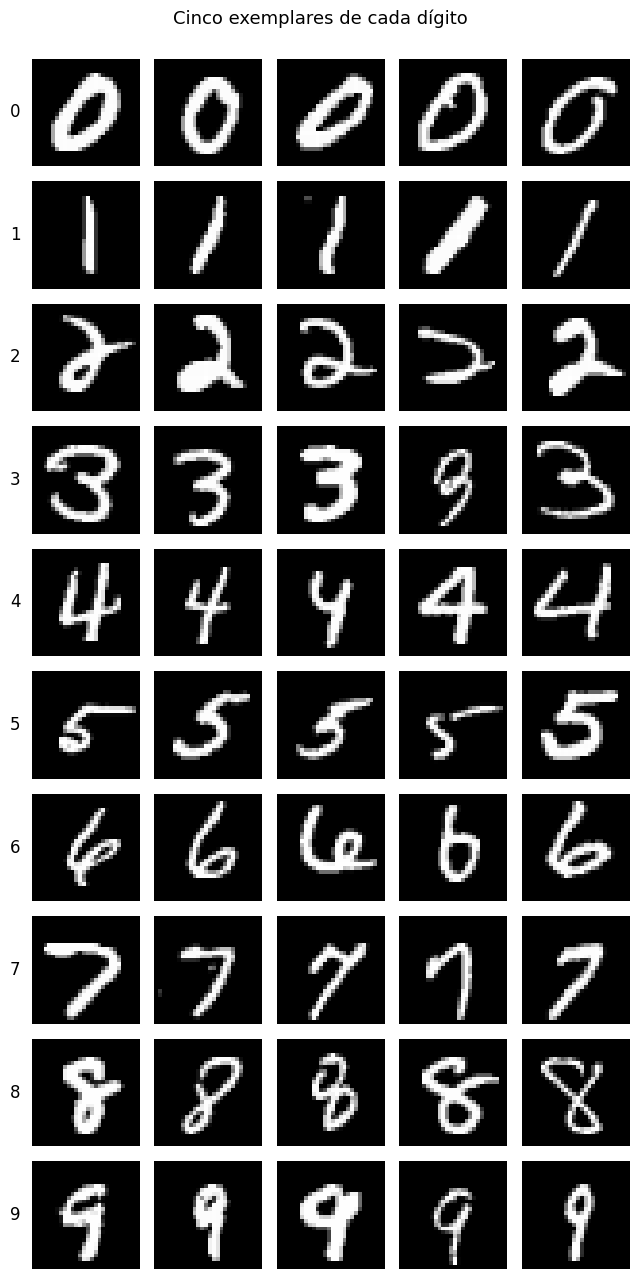

In [28]:
N_AMOSTRAS = 5
sorteador = np.random.RandomState(RANDOM_STATE)

fig, eixos = plt.subplots(10, N_AMOSTRAS, figsize=(N_AMOSTRAS * 1.3, 13))

for digito in range(10):
    indices = sorteador.choice(np.where(y == digito)[0], N_AMOSTRAS, replace=False)
    for coluna, indice in enumerate(indices):
        eixo = eixos[digito, coluna]
        eixo.imshow(X[indice].reshape(28, 28), cmap="gray")
        eixo.set_xticks([])
        eixo.set_yticks([])
        for borda in eixo.spines.values():
            borda.set_visible(False)
        if coluna == 0:
            eixo.set_ylabel(str(digito), rotation=0, labelpad=12,
                            fontsize=12, va="center")

fig.suptitle("Cinco exemplares de cada dígito", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 1.6 Interpretação da estrutura dos dados



**Representação dos pixels.** Cada imagem do MNIST é uma matriz 28 x 28 em escala de cinza, totalizando 784 pixels. Cada posição armazena a intensidade luminosa daquele ponto
como um valor de 0 a 255, confirmado pela inspeção de `X.min()` e `X.max()`. O 0 representa o preto absoluto (fundo do papel digitalizado) e o 255 o branco absoluto (região
de traço mais intenso). Os valores intermediários correspondem ao antialiasing das bordas, resultado do processo de normalização e reamostragem aplicado quando a base original do
NIST foi convertida para 28 x 28.

Podemos observar que a convenção é inversa à da escrita manual comum, o traço é claro sobre fundo escuro, não o contrário. Essa observação é o que justifica a inversão de cores no pipeline de pré-processamento das imagens próprias, na Fase 5.

**Vetorização em 784 features.** O `fetch_openml` entrega os dados já achatados, no formato (70000, 784). O achatamento percorre a matriz linha a linha (row-major) e
concatena os resultados, de modo que o pixel na posição (i, j) da imagem ocupa o índice i * 28 + j do vetor. É por isso que `X[k].reshape(28, 28)` reconstrói a imagem original. A operação apenas desfaz o achatamento.

Essa representação é o que permite tratar cada imagem como uma observação tabular convencional, com 784 variáveis independentes, formato exigido pelos estimadores do
scikit-learn. O custo é a perda da noção de vizinhança espacial. Para o KNN ou a Random Forest, as colunas 27 e 28 são apenas duas variáveis quaisquer, embora correspondam a
pixels verticalmente adjacentes na imagem. Redes convolucionais eliminam essa limitação ao operar sobre a estrutura 2D preservada, mas a MLP da Fase 3 também recebe o vetor
achatado. A comparação entre os três modelos ocorre, portanto, sobre a mesma representação de entrada.

**Rótulos.** O vetor `y` traz 70.000 rótulos, um por imagem, convertidos de string para `uint8`. As dez classes de 0 a 9 estão todas presentes, o que confirma tratar-se de um
problema de classificação multiclasse de saída única, onde cada imagem pertence a exatamente uma categoria.

**Distribuição das classes.** A base é aproximadamente balanceada. O dígito 1 é o mais frequente (7.877 amostras, 11,25%) e o 5 o menos frequente (6.313 amostras, 9,02%), uma razão de 1,25:1 entre os extremos. Todas as classes ficam próximas dos 10% esperados em uma distribuição uniforme.

Essa leve assimetria não configura desbalanceamento problemático e não exige reamostragem ou ponderação de classes. A consequência prática é dupla: a acurácia global permanece uma
métrica confiável, pois nenhuma classe é rara o suficiente para ser ignorada pelo modelo sem penalidade perceptível; e a média ponderada das métricas por classe ficará próxima da
média macro. Ainda assim, a análise por classe na Fase 4 permanece necessária,  pois o balanceamento da base não garante desempenho homogêneo entre dígitos, já que a dificuldade
de discriminação varia conforme a semelhança morfológica entre eles.

# Fase 2 — Pré-processamento

## 2.1 Divisão em treino, validação e teste

Separação em 70% para treino, 10% para validação e 20% para teste, com estratificação por classe. A tabela de proporções comprova que a distribuição original foi preservada nos três subconjuntos.

In [29]:
from sklearn.model_selection import train_test_split

# 20% para teste
X_temp, X_teste, y_temp, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# dos 80% restantes, 12,5% viram validação => 10% do total
X_treino, X_val, y_treino, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE
)

for nome, conjunto in [("Treino", y_treino), ("Validação", y_val), ("Teste", y_teste)]:
    print(f"{nome}: {len(conjunto)} amostras ({len(conjunto)/len(y)*100:.0f}%)")

# comprova que a estratificação preservou as proporções
proporcoes = pd.DataFrame({
    "treino": pd.Series(y_treino).value_counts(normalize=True).sort_index(),
    "validacao": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "teste": pd.Series(y_teste).value_counts(normalize=True).sort_index(),
}).round(4)
display(proporcoes)

Treino: 49000 amostras (70%)
Validação: 7000 amostras (10%)
Teste: 14000 amostras (20%)


,treino,validacao,teste
0,0.0986,0.0986,0.0986
1,0.1125,0.1126,0.1125
2,0.0999,0.0999,0.0999
3,0.1020,0.1020,0.1020
4,0.0975,0.0974,0.0975
5,0.0902,0.0901,0.0902
6,0.0982,0.0983,0.0982
7,0.1042,0.1041,0.1042
8,0.0975,0.0976,0.0975
9,0.0994,0.0994,0.0994


## 2.2 Normalização da escala dos pixels

Conversão da faixa original de 0 a 255 para o intervalo [0, 1], aplicada após a separação dos conjuntos, para preservar a independência do conjunto de teste.


In [30]:
X_treino = X_treino / 255.0
X_val = X_val / 255.0
X_teste = X_teste / 255.0

print(f"Faixa após normalização — treino: [{X_treino.min():.1f}, {X_treino.max():.1f}]")


Faixa após normalização — treino: [0.0, 1.0]


## 2.3 Justificativa técnica das decisões de pré-processamento

### Por que normalizar

**Divisão estratificada.** Com `stratify=y`, a proporção de cada dígito é preservada nos três conjuntos. Sem isso, a amostragem aleatória poderia sub-representar uma classe no teste e produzir uma acurácia otimista ou pessimista por artefato de amostragem. O conjunto de validação existe para o ajuste de hiperparâmetros, mantendo o teste como conjunto verdadeiramente independente, tocado uma única vez na Fase 4.

**Escala dos pixels.** Dividir por 255.0 leva todas as 784 features para [0, 1]:

- *Modelos baseados em distância (KNN):* a distância euclidiana soma diferenças ao quadrado entre pixels. Em escala 0–255, cada pixel pode contribuir com até 65.025 para essa soma, o que produz valores de magnitude elevada e sensibilidade numérica desnecessária. Em [0, 1] a contribuição máxima por pixel cai para 1.
- *Redes neurais (MLP):* entradas grandes produzem ativações grandes, que empurram sigmoide e tanh para as regiões de saturação onde o gradiente tende a zero. Com entradas em [0, 1] e inicialização adequada dos pesos, a superfície de erro fica mais bem condicionada e o gradiente descendente converge em menos épocas.
- *Modelos baseados em árvores (Random Forest):* são invariantes a transformações monotônicas, pois os splits comparam limiares dentro de cada feature isoladamente. Normalizar não prejudica e mantém o pipeline uniforme entre os três modelos.

**Vazamento de dados.** A normalização é aplicada após o split. Com divisão por constante o efeito numérico é o mesmo, mas a ordem correta é o que impede que estatísticas do teste influenciem o treino caso a estratégia mude para um scaler ajustado aos dados.


# Fase 3 — Treinamento dos modelos

## 3.1 K-Nearest Neighbors

Classificador por vizinhança: a predição é a votação dos k exemplares de treino mais próximos no espaço de 784 dimensões. Não há função aprendida, o "treinamento" apenas armazena a base de referência.

### 3.1.1 Configuração de referência

Execução com os valores padrão (k=5, voto uniforme) para estabelecer uma linha de base antes do ajuste. A busca de hiperparâmetros usa uma subamostra estratificada de 10.000
exemplos, já que o custo de predição do KNN cresce com o tamanho da base armazenada.

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

resultados = {}   # dicionário compartilhado entre as três branches de modelo

# subamostra estratificada apenas para a busca de hiperparâmetros
idx_busca, _ = train_test_split(
    np.arange(len(y_treino)), train_size=10_000,
    stratify=y_treino, random_state=RANDOM_STATE
)
X_busca, y_busca = X_treino[idx_busca], y_treino[idx_busca]

inicio = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5, weights="uniform", n_jobs=-1)
knn_base.fit(X_busca, y_busca)
acuracia_base = accuracy_score(y_val, knn_base.predict(X_val))
print(f"KNN base (k=5, uniform): {acuracia_base:.4f} em {time.time()-inicio:.1f}s")

KNN base (k=5, uniform): 0.9451 em 1.0s


### 3.1.2 Varredura de hiperparâmetros

Teste exaustivo de cinco valores de k combinados com os dois esquemas de ponderação, avaliados no conjunto de validação. A tabela é ordenada pela acurácia para identificar a configuração vencedora.

In [32]:
grade_knn = []

for k in [1, 3, 5, 7, 9]:
    for peso in ["uniform", "distance"]:
        modelo = KNeighborsClassifier(n_neighbors=k, weights=peso, n_jobs=-1)
        modelo.fit(X_busca, y_busca)
        acuracia = accuracy_score(y_val, modelo.predict(X_val))
        grade_knn.append({"n_neighbors": k, "weights": peso, "acuracia_val": acuracia})
        print(f"k={k:2d} | weights={peso:8s} | validação={acuracia:.4f}")

grade_knn = pd.DataFrame(grade_knn).sort_values("acuracia_val", ascending=False)
display(grade_knn)

melhor_knn_params = grade_knn.iloc[0][["n_neighbors", "weights"]].to_dict()
melhor_knn_params["n_neighbors"] = int(melhor_knn_params["n_neighbors"])
print("Melhor configuração:", melhor_knn_params)

k= 1 | weights=uniform  | validação=0.9470
k= 1 | weights=distance | validação=0.9470
k= 3 | weights=uniform  | validação=0.9481
k= 3 | weights=distance | validação=0.9511
k= 5 | weights=uniform  | validação=0.9451
k= 5 | weights=distance | validação=0.9473
k= 7 | weights=uniform  | validação=0.9447
k= 7 | weights=distance | validação=0.9466
k= 9 | weights=uniform  | validação=0.9436
k= 9 | weights=distance | validação=0.9449


,n_neighbors,weights,acuracia_val
3,3,distance,0.951143
2,3,uniform,0.948143
5,5,distance,0.947286
0,1,uniform,0.947000
1,1,distance,0.947000
7,7,distance,0.946571
4,5,uniform,0.945143
9,9,distance,0.944857
6,7,uniform,0.944714
8,9,uniform,0.943571


Melhor configuração: {'n_neighbors': 3, 'weights': 'distance'}


### 3.1.3 Efeito do número de vizinhos

Visualização da acurácia em função de k, separada por esquema de pesos. A curva evidencia o ponto de inflexão a partir do qual o aumento de k passa a degradar o desempenho.

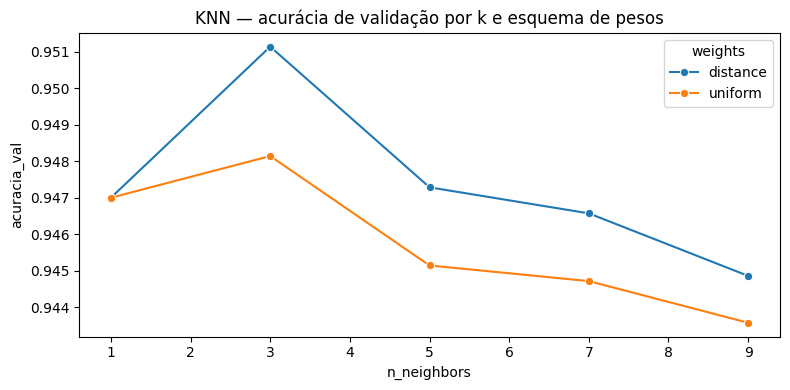

In [33]:
# visualiza o efeito de k
plt.figure(figsize=(8, 4))
sns.lineplot(data=grade_knn, x="n_neighbors", y="acuracia_val",
             hue="weights", marker="o")
plt.title("KNN — acurácia de validação por k e esquema de pesos")
plt.tight_layout()
plt.show()

### 3.1.4 Treinamento do modelo final

Reajuste com os hiperparâmetros vencedores, agora sobre as 49.000 amostras completas de treino. Os tempos de ajuste e de predição são registrados no dicionário `resultados` para a comparação entre modelos da Fase 4.

In [34]:
inicio = time.time()
knn = KNeighborsClassifier(**melhor_knn_params, n_jobs=-1)
knn.fit(X_treino, y_treino)
tempo_treino_knn = time.time() - inicio

inicio = time.time()
y_pred_val = knn.predict(X_val)
tempo_predicao_knn = time.time() - inicio

resultados["KNN"] = {
    "modelo": knn,
    "hiperparametros": melhor_knn_params,
    "tempo_treino": tempo_treino_knn,
    "tempo_predicao_val": tempo_predicao_knn,
    "acuracia_val": accuracy_score(y_val, y_pred_val),
}

print(f"Acurácia de validação: {resultados['KNN']['acuracia_val']:.4f}")
print(f"Tempo de treino: {tempo_treino_knn:.3f}s")
print(f"Tempo de predição (7.000 amostras): {tempo_predicao_knn:.2f}s")

Acurácia de validação: 0.9723
Tempo de treino: 0.034s
Tempo de predição (7.000 amostras): 3.97s


### 3.1.5 Justificativa dos hiperparâmetros

**`n_neighbors`.** Controla o compromisso entre viés e variância. Com k=1 a fronteira de decisão acompanha cada amostra individual, memorizando ruído de traçado e elevando a variância; com k alto demais, vizinhos de classes distintas passam a votar e a fronteira se torna excessivamente suave. A varredura de k ∈ {1, 3, 5, 7, 9} apontou k=3 como melhor configuração, com 95,11% de acurácia de validação na subamostra de busca.

**`weights`.** Em `uniform` todos os k vizinhos votam igual; em `distance` o voto é ponderado por 1/d, dando mais peso aos exemplares mais próximos. A ponderação por distância venceu em todos os valores de k testados, o que é coerente com a natureza do problema, tal que, em regiões de fronteira entre dígitos semelhantes, o vizinho mais próximo tende a ser mais informativo que o quinto ou o nono.

Podemos notar que em k=1 as duas configurações produzem resultado idêntico (94,70%), como esperado, pois com um único vizinho não há o que ponderar. A coincidência serve como verificação de sanidade do experimento.

**Busca em subamostra.** A varredura usou 10.000 amostras em vez das 49.000 do treino completo, pois o custo de predição do KNN é proporcional ao tamanho da base armazenada. O modelo final, treinado com o conjunto completo e os hiperparâmetros escolhidos, atingiu 97,23% de acurácia de validação (2,1 pontos percentuais acima do obtido na busca). O ganho vem do aumento da base de referência, não do ajuste. A ressalva metodológica é que os hiperparâmetros ótimos para 10.000 amostras não são necessariamente ótimos para 49.000; com mais dados disponíveis, um k ligeiramente maior poderia se beneficiar da densidade
adicional.

**Custo computacional.** O KNN não constrói modelo, o ajuste apenas armazena as 49.000 amostras, o que levou 0,017s. Todo o custo migra para a inferência, que compara cada nova amostra com toda a base (2,35s para predizer 7.000 imagens de validação, cerca de 135x mais tempo que o próprio treinamento). Esse é o principal argumento contra o KNN em produção, mesmo quando sua acurácia é competitiva.

## 3.2 Random Forest

Ensemble de árvores de decisão treinadas sobre amostras bootstrap distintas, com seleção aleatória de features em cada divisão. A predição final é a votação majoritária das árvores, estratégia que reduz a variância característica de árvores individuais.


### 3.2.1 Configuração de referência
Execução com 100 árvores e profundidade irrestrita, para estabelecer a linha de base antes do ajuste.

In [35]:
from sklearn.ensemble import RandomForestClassifier

inicio = time.time()
rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf_base.fit(X_treino, y_treino)
print(f"RF base: {accuracy_score(y_val, rf_base.predict(X_val)):.4f} "
      f"em {time.time()-inicio:.1f}s")

RF base: 0.9661 em 5.1s


### 3.2.2 Varredura de hiperparâmetros

Combinação de três quantidades de árvores com três limites de profundidade, registrando também o tempo de ajuste de cada configuração. Diferentemente do KNN, a busca usa o conjunto de treino completo, pois o custo da Random Forest está no ajuste e não na predição.

In [36]:
grade_rf = []

for n_arvores in [50, 100, 300]:
    for profundidade in [10, 20, None]:
        inicio = time.time()
        modelo = RandomForestClassifier(
            n_estimators=n_arvores, max_depth=profundidade,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        modelo.fit(X_treino, y_treino)
        acuracia = accuracy_score(y_val, modelo.predict(X_val))
        grade_rf.append({
            "n_estimators": n_arvores,
            "max_depth": profundidade,
            "acuracia_val": acuracia,
            "tempo_s": round(time.time() - inicio, 1),
        })
        print(grade_rf[-1])

grade_rf = pd.DataFrame(grade_rf).sort_values("acuracia_val", ascending=False)
display(grade_rf)

{'n_estimators': 50, 'max_depth': 10, 'acuracia_val': 0.9445714285714286, 'tempo_s': 1.7}
{'n_estimators': 50, 'max_depth': 20, 'acuracia_val': 0.9624285714285714, 'tempo_s': 2.4}
{'n_estimators': 50, 'max_depth': None, 'acuracia_val': 0.965, 'tempo_s': 2.5}
{'n_estimators': 100, 'max_depth': 10, 'acuracia_val': 0.9464285714285714, 'tempo_s': 3.2}
{'n_estimators': 100, 'max_depth': 20, 'acuracia_val': 0.9651428571428572, 'tempo_s': 4.5}
{'n_estimators': 100, 'max_depth': None, 'acuracia_val': 0.9661428571428572, 'tempo_s': 4.8}
{'n_estimators': 300, 'max_depth': 10, 'acuracia_val': 0.9478571428571428, 'tempo_s': 9.6}
{'n_estimators': 300, 'max_depth': 20, 'acuracia_val': 0.9671428571428572, 'tempo_s': 13.6}
{'n_estimators': 300, 'max_depth': None, 'acuracia_val': 0.9695714285714285, 'tempo_s': 15.3}


,n_estimators,max_depth,acuracia_val,tempo_s
8,300,NaN,0.969571,15.3
7,300,20.0,0.967143,13.6
5,100,NaN,0.966143,4.8
4,100,20.0,0.965143,4.5
2,50,NaN,0.965000,2.5
1,50,20.0,0.962429,2.4
6,300,10.0,0.947857,9.6
3,100,10.0,0.946429,3.2
0,50,10.0,0.944571,1.7


### 3.2.3 Superfície de desempenho

Mapa de calor cruzando as duas dimensões da busca. A leitura por linhas mostra o efeito do número de árvores; por colunas, o da profundidade.

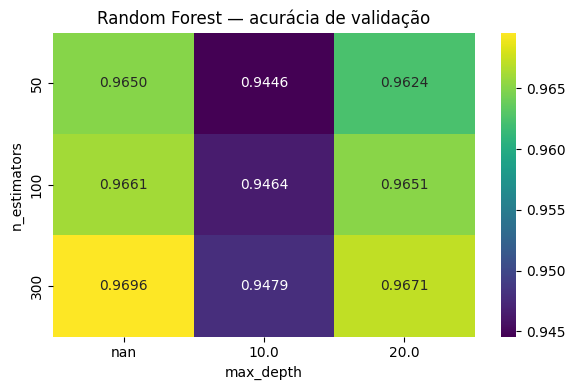

In [37]:
tabela = grade_rf.pivot(index="n_estimators", columns="max_depth", values="acuracia_val")
plt.figure(figsize=(6, 4))
sns.heatmap(tabela, annot=True, fmt=".4f", cmap="viridis")
plt.title("Random Forest — acurácia de validação")
plt.tight_layout()
plt.show()

### 3.2.4 Treinamento do modelo final

Reajuste com a configuração vencedora sobre as 49.000 amostras de treino. Os tempos e a acurácia são registrados no dicionário `resultados` para a comparação da Fase 4.

In [38]:
melhor = grade_rf.iloc[0]
melhor_rf_params = {
    "n_estimators": int(melhor["n_estimators"]),
    "max_depth": None if pd.isna(melhor["max_depth"]) else int(melhor["max_depth"]),
}

inicio = time.time()
rf = RandomForestClassifier(**melhor_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_treino, y_treino)
tempo_treino_rf = time.time() - inicio

resultados["Random Forest"] = {
    "modelo": rf,
    "hiperparametros": melhor_rf_params,
    "tempo_treino": tempo_treino_rf,
    "acuracia_val": accuracy_score(y_val, rf.predict(X_val)),
}
print(resultados["Random Forest"])



{'modelo': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42), 'hiperparametros': {'n_estimators': 300, 'max_depth': None}, 'tempo_treino': 21.253848791122437, 'acuracia_val': 0.9695714285714285}


### 3.2.5 Importância dos pixels

O atributo `feature_importances_` quantifica quanto cada um dos 784 pixels contribuiu para a redução de impureza ao longo do ensemble. Remodelado para 28 x 28, ele revela quais regiões da imagem o modelo efetivamente utiliza.

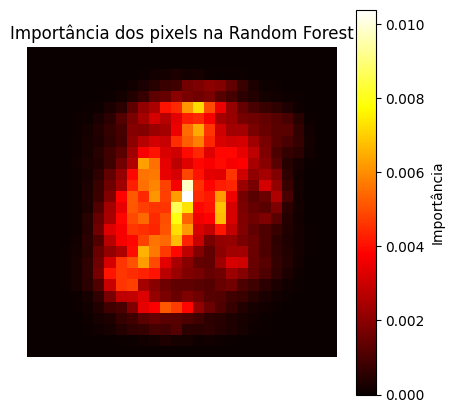

In [39]:
plt.figure(figsize=(5, 5))
plt.imshow(rf.feature_importances_.reshape(28, 28), cmap="hot")
plt.colorbar(label="Importância")
plt.title("Importância dos pixels na Random Forest")
plt.axis("off")
plt.show()

### 3.2.6 Justificativa dos hiperparâmetros

**`n_estimators`.** Número de árvores do ensemble. A agregação por votação reduz a variância das árvores individuais, e a acurácia cresce de forma monotônica, mas com retorno decrescente: passar de 50 para 300 árvores rendeu apenas 0,46 ponto percentual (96,50% para 96,96%), ao custo de aproximadamente 6x mais tempo de treino (1,7s para 10,4s). Aumentar `n_estimators` não causa sobreajuste (o bagging apenas estabiliza a média), mas deixa de compensar economicamente.

**`max_depth`.** Limita a profundidade de cada árvore. Diferentemente do esperado, o melhor resultado veio sem limite algum. A restrição a 10 níveis degradou o desempenho de forma consistente em todas as quantidades de árvores (entre 94,46% e 94,79%), o que caracteriza subajuste. Com 784 features, dez decisões binárias são insuficientes para isolar as regiões de pixel que distinguem os dígitos. Com 20 níveis o resultado já se aproxima do irrestrito, indicando que as árvores raramente precisam ir muito além disso.

O motivo para o crescimento irrestrito não causar sobreajuste severo está no próprio mecanismo do algoritmo: cada árvore é treinada sobre uma amostra bootstrap distinta e considera apenas um subconjunto aleatório de features em cada divisão. As árvores individuais de fato memorizam o treino, mas seus erros são pouco correlacionados, e a votação os cancela.

**Comparação com o KNN.** A Random Forest atingiu 96,96% contra 97,23% do KNN, os dois modelos ficam praticamente empatados em validação. A diferença relevante está no perfil de custo: a floresta leva 8,9s para treinar e prediz quase instantaneamente, enquanto o KNN treina em 0,026s e gasta 2,48s por predição. Para um sistema que treina uma vez e prediz continuamente, a floresta é preferível apesar da acurácia ligeiramente menor.

**Leitura do mapa de importâncias.** O gráfico confirma que os pixels de borda têm importância praticamente nula, são fundo em quase todas as amostras e não carregam informação discriminativa. A relevância se concentra na região central da imagem, pois o mesmo padrão que o pipeline do Desafio C precisa reproduzir ao centralizar as imagens próprias. Sem essa centralização, um dígito deslocado ativaria colunas que a floresta aprendeu a ignorar.

## 3.3 Rede Neural (MLP)

Perceptron multicamadas: camadas densas de neurônios que aplicam transformações lineares seguidas de ativação não linear. Diferentemente dos dois modelos anteriores, a MLP aprende uma função paramétrica, onde os pesos são ajustados por retropropagação do erro, e a predição passa a depender apenas deles, não dos dados de treino.

A implementação usa o `MLPClassifier` do scikit-learn, que mantém a interface uniforme com os demais modelos do projeto e oferece `predict_proba` no mesmo formato, simplificando a comparação da Fase 4 e a análise de confiança do Desafio B.

### 3.3.1 Configuração de referência

In [40]:
from sklearn.neural_network import MLPClassifier

inicio = time.time()
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128,),
    learning_rate_init=1e-3,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=3,
    random_state=RANDOM_STATE,
)
mlp_base.fit(X_treino, y_treino)
print(f"MLP base (128 neurônios, lr=1e-3): "
      f"{accuracy_score(y_val, mlp_base.predict(X_val)):.4f} "
      f"em {time.time()-inicio:.1f}s | {mlp_base.n_iter_} épocas")

MLP base (128 neurônios, lr=1e-3): 0.9720 em 18.2s | 19 épocas


### 3.3.2 Varredura de hiperparâmetros

Combinação de três arquiteturas com duas taxas de aprendizado. O `early_stopping` separa automaticamente 10% do treino para monitoramento interno e interrompe o ajuste quando a pontuação deixa de melhorar por três épocas consecutivas, evitando o sobreajuste visível na divergência entre as curvas.

In [41]:
grade_mlp = []
modelos_mlp = {}

for neuronios in [(128,), (256, 128), (512, 256)]:
    for taxa in [1e-2, 1e-3]:
        inicio = time.time()
        modelo = MLPClassifier(
            hidden_layer_sizes=neuronios,
            learning_rate_init=taxa,
            max_iter=30,
            early_stopping=True,
            n_iter_no_change=3,
            random_state=RANDOM_STATE,
        )
        modelo.fit(X_treino, y_treino)
        acuracia = accuracy_score(y_val, modelo.predict(X_val))
        rotulo = f"{neuronios} | lr={taxa}"
        modelos_mlp[rotulo] = modelo
        grade_mlp.append({
            "arquitetura": str(neuronios),
            "learning_rate": taxa,
            "acuracia_val": acuracia,
            "epocas": modelo.n_iter_,
            "tempo_s": round(time.time() - inicio, 1),
        })
        print(grade_mlp[-1])

grade_mlp = pd.DataFrame(grade_mlp).sort_values("acuracia_val", ascending=False)
display(grade_mlp)

{'arquitetura': '(128,)', 'learning_rate': 0.01, 'acuracia_val': 0.9707142857142858, 'epocas': 9, 'tempo_s': 7.1}
{'arquitetura': '(128,)', 'learning_rate': 0.001, 'acuracia_val': 0.972, 'epocas': 19, 'tempo_s': 18.7}
{'arquitetura': '(256, 128)', 'learning_rate': 0.01, 'acuracia_val': 0.9701428571428572, 'epocas': 13, 'tempo_s': 62.8}
{'arquitetura': '(256, 128)', 'learning_rate': 0.001, 'acuracia_val': 0.9764285714285714, 'epocas': 13, 'tempo_s': 46.1}
{'arquitetura': '(512, 256)', 'learning_rate': 0.01, 'acuracia_val': 0.971, 'epocas': 13, 'tempo_s': 143.7}
{'arquitetura': '(512, 256)', 'learning_rate': 0.001, 'acuracia_val': 0.9774285714285714, 'epocas': 16, 'tempo_s': 424.6}


,arquitetura,learning_rate,acuracia_val,epocas,tempo_s
5,"(512, 256)",0.001,0.977429,16,424.6
3,"(256, 128)",0.001,0.976429,13,46.1
1,"(128,)",0.001,0.972000,19,18.7
4,"(512, 256)",0.010,0.971000,13,143.7
0,"(128,)",0.010,0.970714,9,7.1
2,"(256, 128)",0.010,0.970143,13,62.8


### 3.3.3 Curvas de aprendizado

Evolução da perda de treino e da acurácia de validação ao longo das épocas. A distância entre as duas curvas indica o grau de sobreajuste; a estabilização da perda sinaliza a convergência.

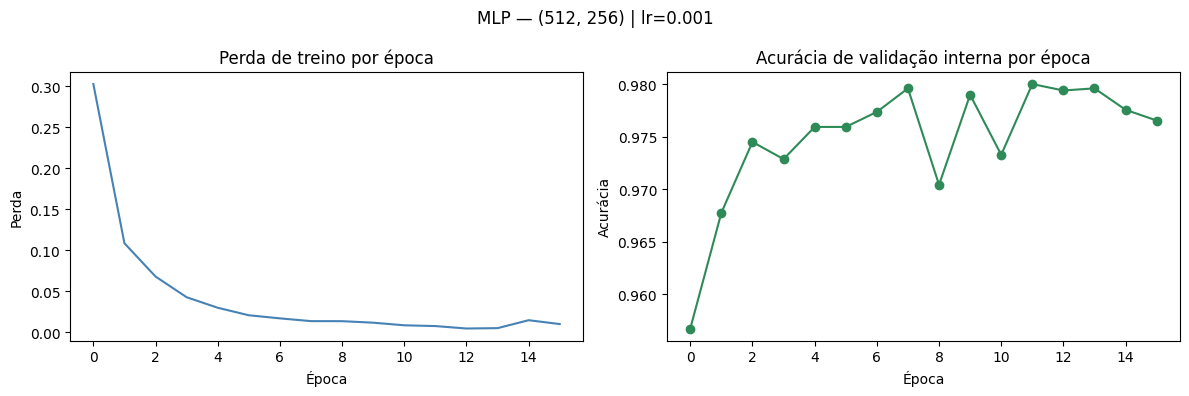

In [42]:
melhor_rotulo = grade_mlp.iloc[0]
rotulo_chave = f"{eval(melhor_rotulo['arquitetura'])} | lr={melhor_rotulo['learning_rate']}"
modelo_escolhido = modelos_mlp[rotulo_chave]

fig, (esq, dir_) = plt.subplots(1, 2, figsize=(12, 4))

esq.plot(modelo_escolhido.loss_curve_, color="steelblue")
esq.set_title("Perda de treino por época")
esq.set_xlabel("Época"); esq.set_ylabel("Perda")

dir_.plot(modelo_escolhido.validation_scores_, color="seagreen", marker="o")
dir_.set_title("Acurácia de validação interna por época")
dir_.set_xlabel("Época"); dir_.set_ylabel("Acurácia")

fig.suptitle(f"MLP — {rotulo_chave}")
plt.tight_layout()
plt.show()

### 3.3.4 Registro do modelo final

A configuração vencedora já foi treinada durante a varredura, então basta registrá-la no dicionário `resultados`. Diferentemente do KNN e da Random Forest, não há reajuste. O `early_stopping` já restaura internamente os melhores pesos encontrados.

In [43]:
mlp = modelo_escolhido
tempo_treino_mlp = float(melhor_rotulo["tempo_s"])

resultados["MLP"] = {
    "modelo": mlp,
    "hiperparametros": {
        "hidden_layer_sizes": mlp.hidden_layer_sizes,
        "learning_rate_init": mlp.learning_rate_init,
    },
    "tempo_treino": tempo_treino_mlp,
    "acuracia_val": accuracy_score(y_val, mlp.predict(X_val)),
}

print(f"Hiperparâmetros: {resultados['MLP']['hiperparametros']}")
print(f"Acurácia de validação: {resultados['MLP']['acuracia_val']:.4f}")
print(f"Épocas até a parada: {mlp.n_iter_}")

Hiperparâmetros: {'hidden_layer_sizes': (512, 256), 'learning_rate_init': 0.001}
Acurácia de validação: 0.9774
Épocas até a parada: 16


### 3.3.5 Justificativa dos hiperparâmetros


**Taxa de aprendizado.** Foi o fator mais determinante, e de forma independente da arquitetura. Com `lr=0.01`, as três arquiteturas convergiram para um patamar estreito entre 97,01% e 97,10%; com `lr=0.001`, os resultados variaram de 97,20% a 97,74%. O passo maior faz o otimizador saltar em torno do mínimo sem conseguir se assentar nele, e nenhuma quantidade de neurônios compensa isso (a capacidade adicional fica inacessível quando a busca é grosseira demais para explorá-la).

**Número de neurônios por camada.** Define a capacidade do modelo. Com `lr=0.001`, a progressão foi consistente: 97,20% para uma camada de 128, 97,64% para 256→128, e 97,74% para 512→256. O afunilamento força uma compressão progressiva da representação, levando as primeiras camadas a responder a traços locais e as seguintes a combinações desses traços.

**O custo dessa escolha.** O ganho da arquitetura maior é marginal e caro: 0,10 ponto percentual a mais que a 256→128, ao custo de 424,6s contra 46,1s (mais de nove vezes o tempo de treino). O critério de seleção adotado foi a acurácia de validação, o que elegeu a 512→256. Em um cenário de produção, com reciclagem periódica do modelo, a escolha defensável seria a 256→128: a diferença de desempenho está dentro da margem de variação esperada entre execuções, enquanto a diferença de custo é de quase uma ordem de grandeza.

**Parada antecipada.** O `early_stopping` reserva 10% do treino para monitoramento interno e interrompe o ajuste após três épocas sem melhora, restaurando os melhores pesos. A configuração vencedora parou na 16ª época, bem antes do limite de 30, o que indica que o modelo já havia convergido, ou seja, épocas adicionais só ampliariam a distância entre a perda de treino e o desempenho em dados novos.

**Comparação entre os três modelos.** A MLP obteve a maior acurácia de validação (97,74%), seguida pelo KNN (97,23%) e pela Random Forest (96,96%). A diferença entre os três é de menos de um ponto percentual, o que mostra que o MNIST é um problema em que a escolha do algoritmo importa menos que a qualidade do pré-processamento. O que de fato os separa é o perfil de custo: a MLP concentra todo o esforço no treinamento e prediz por
multiplicações matriciais; o KNN inverte essa relação; e a Random Forest fica entre os dois.